### Plot Generation programs ###

['Base' 'Fine-tuned']
['Mistral-7B-Instructv0.3' 'DeepSeek-Coder 6.7B-Instruct'
 'Qwen2.5-7B-Instruct']

✅ Raw Base Model Data Before Melt:
                          Model Fine-Tuning Status  pass@1  pass@3  pass@5
0       Mistral-7B-Instructv0.3               Base     0.2     0.3    0.55
2  DeepSeek-Coder 6.7B-Instruct               Base     0.3     0.4    0.50
4           Qwen2.5-7B-Instruct               Base     0.2     0.4    0.50

✅ Data Types:
Model                  object
Fine-Tuning Status     object
pass@1                float64
pass@3                float64
pass@5                float64
dtype: object


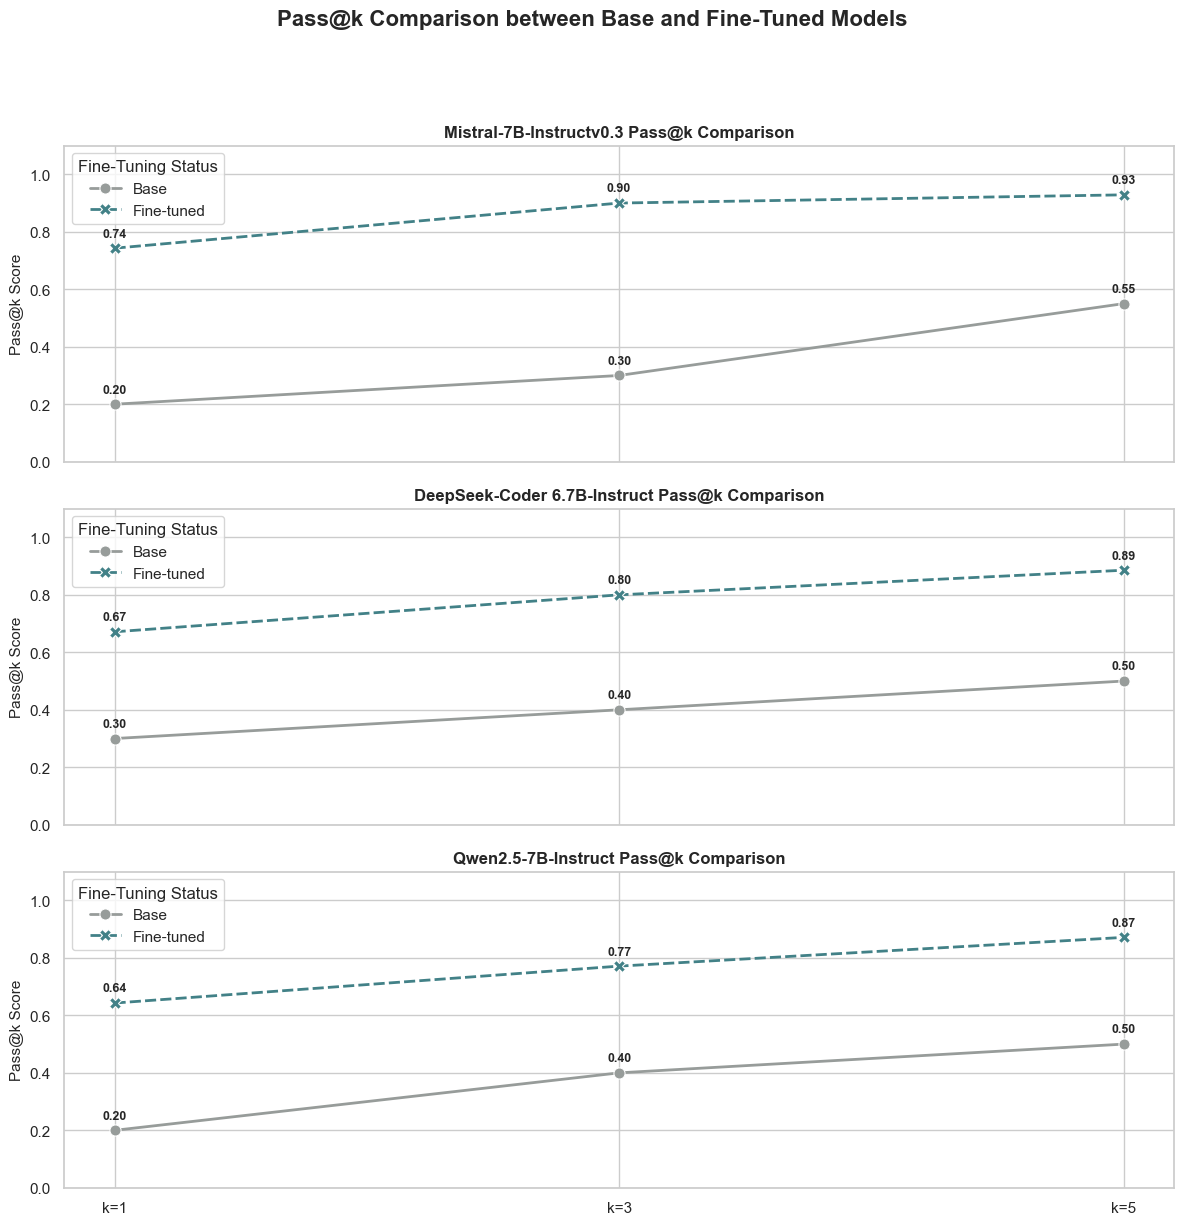

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from CSV
df = pd.read_csv("pass_k_summary_70.csv")

# Clean Model and Fine-Tuning Status to remove leading/trailing spaces
df["Model"] = df["Model"].str.strip()
df["Fine-Tuning Status"] = df["Fine-Tuning Status"].str.strip()

# Melt the DataFrame to have a single value column and a metric column
df_melted = pd.melt(
    df,
    id_vars=["Model", "Fine-Tuning Status"],
    value_vars=["pass@1", "pass@3", "pass@5"],
    var_name="Metric",
    value_name="Score"
)

# Extract k values from Metric (e.g., "pass@1" -> 1)
df_melted["k"] = df_melted["Metric"].str.extract(r"pass@(\d+)").astype(int)

# Define color palette
palette = {"Base": "#979c9a", "Fine-tuned": "#428187"}

# Define line styles (solid for Fine-tuned, dashed for Base)
styles = {"Base": "--", "Fine-tuned": "-"}

# Seaborn style
sns.set(style="whitegrid")

# Create figure with 3 subplots stacked vertically
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Add main title
fig.suptitle("Pass@k Comparison between Base and Fine-Tuned Models", fontsize=16, weight='bold', y=1.02)

# Models to plot
models = df["Model"].unique()
print(df["Fine-Tuning Status"].unique())
print(df["Model"].unique())
# Debug: Show all rows for one Base model
print("\n✅ Raw Base Model Data Before Melt:")
base_df = df[df["Fine-Tuning Status"] == "Base"]
print(base_df)

# Check dtypes
print("\n✅ Data Types:")
print(base_df.dtypes)


# Plot for each model
for idx, model in enumerate(models):
    ax = axes[idx]
    subset = df_melted[df_melted["Model"] == model]
    sns.lineplot(
        data=subset,
        x="k",
        y="Score",
        hue="Fine-Tuning Status",
        style="Fine-Tuning Status",
        palette=palette,
        markers=True,
        dashes=True,
        linewidth=2,
        markersize=8,
        ax=ax
    )

    # Annotate points
    for line in ax.lines:
        xdata = line.get_xdata()
        ydata = line.get_ydata()
        for x, y in zip(xdata, ydata):
            if y > 0.05:
                ax.annotate(
                    f"{y:.2f}",
                    (x, y + 0.03),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    fontweight='bold'
                )

    # Set subplot title and labels
    ax.set_title(f"{model} Pass@k Comparison", fontsize=12, weight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Pass@k Score", fontsize=11)
    ax.set_xlabel("", fontsize=11)
    ax.set_xticks([1, 3, 5])
    ax.set_xticklabels(["k=1", "k=3", "k=5"])

# Remove global x/y axis labels
# fig.text(0.5, 0.04, "", ha='center', fontsize=12)
# fig.text(0.04, 0.5, "", va='center', rotation='vertical', fontsize=12)

# Add a single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, title="Model Type", loc='upper right', bbox_to_anchor=(0.98, 0.98), ncol=1)

# Final layout
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("Fig11.png", dpi=300, bbox_inches='tight')
plt.show()


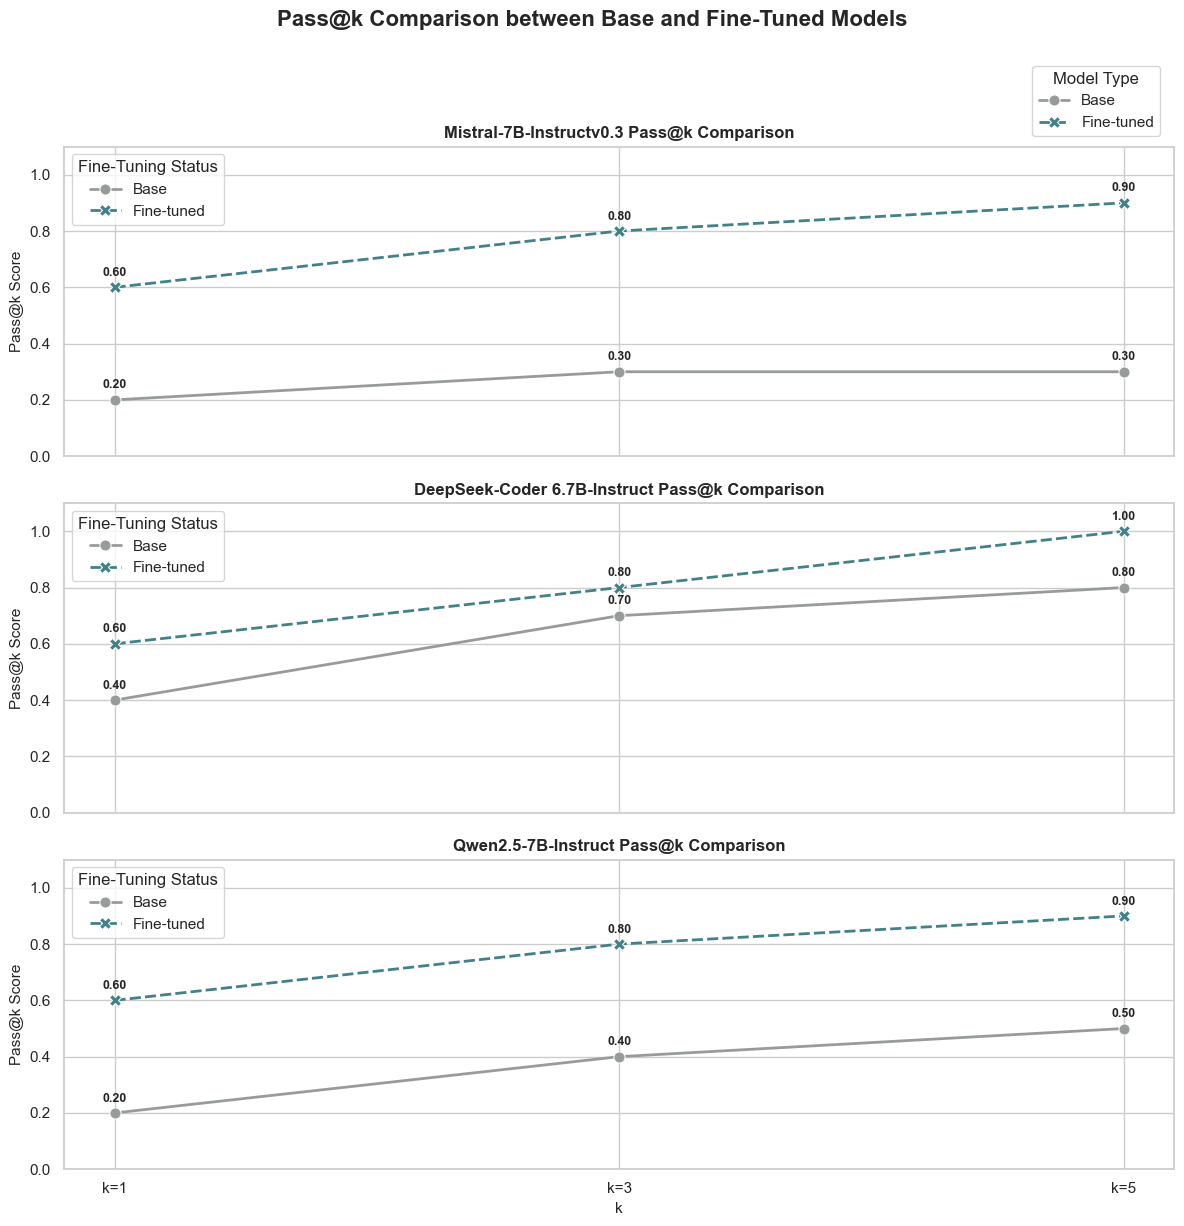

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from CSV
df = pd.read_csv("pass_k_summary.csv")

# Clean Model and Fine-Tuning Status to remove leading/trailing spaces
df["Model"] = df["Model"].str.strip()
df["Fine-Tuning Status"] = df["Fine-Tuning Status"].str.strip()

# Melt the DataFrame to have a single value column and a metric column
df_melted = pd.melt(
    df,
    id_vars=["Model", "Fine-Tuning Status"],
    value_vars=["pass@1", "pass@3", "pass@5"],
    var_name="Metric",
    value_name="Score"
)

# Extract k values from Metric (e.g., "pass@1" -> 1)
df_melted["k"] = df_melted["Metric"].str.extract(r"pass@(\d+)").astype(int)

# Define color palette and styles
palette = {"Base": "#979c9a", "Fine-tuned": "#428187"}
styles = {"Base": "--", "Fine-tuned": "-"}

# Seaborn style
sns.set(style="whitegrid")

# Create figure with 3 subplots stacked vertically
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Set a main title
fig.suptitle("Pass@k Comparison between Base and Fine-Tuned Models", fontsize=16, weight='bold', y=1.02)

# Models to plot
models = df["Model"].unique()

# Plot for each model
for idx, model in enumerate(models):
    ax = axes[idx]
    subset = df_melted[df_melted["Model"] == model]
    sns.lineplot(
        data=subset,
        x="k",
        y="Score",
        hue="Fine-Tuning Status",
        style="Fine-Tuning Status",
        palette=palette,
        markers=True,
        dashes=True,
        linewidth=2,
        markersize=8,
        ax=ax
    )

    # Annotate points with values
    for line in ax.lines:
        xdata = line.get_xdata()
        ydata = line.get_ydata()
        for x, y in zip(xdata, ydata):
            if y > 0.05:
                ax.annotate(
                    f"{y:.2f}",
                    (x, y + 0.03),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    fontweight='bold'
                )

    # Set title and axis labels
    ax.set_title(f"{model} Pass@k Comparison", fontsize=12, weight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Pass@k Score", fontsize=11)
    ax.set_xlabel("k", fontsize=11)
    ax.set_xticks([1, 3, 5])
    ax.set_xticklabels(["k=1", "k=3", "k=5"])

# Add a single legend for all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Model Type", loc='upper right', bbox_to_anchor=(0.98, 0.98), ncol=1)

# Layout and save
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("pass_k_comparison_subplots.png", dpi=300, bbox_inches='tight')
plt.show()


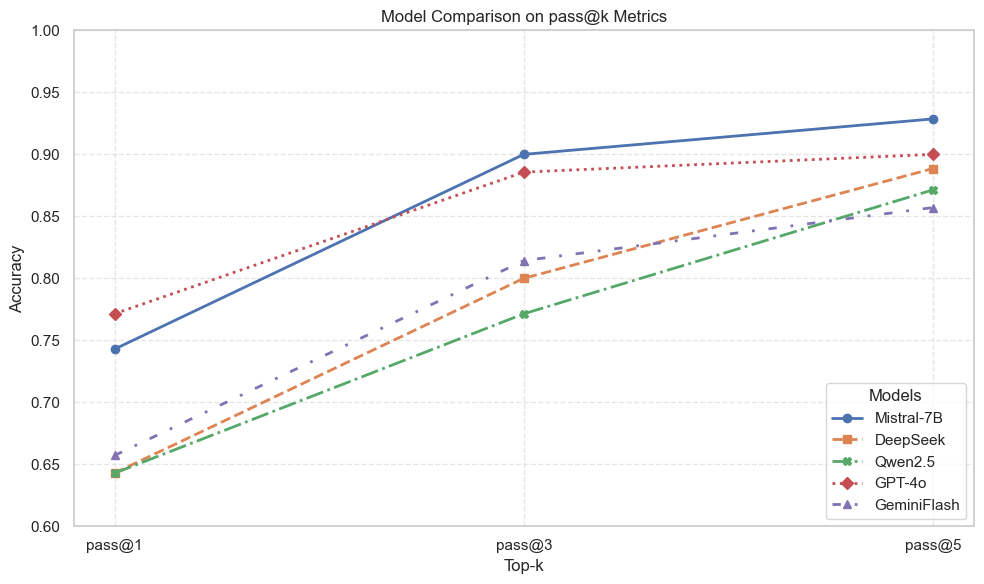

In [ ]:
import matplotlib.pyplot as plt

# X-axis values (k levels)
k_values = [1, 3, 5]

# pass@k scores for each model
model_scores = {
    "Mistral-7B": [0.7429, 0.9, 0.9286],
    "DeepSeek": [0.6429, 0.8, 0.8886],
    "Qwen2.5": [0.6428, 0.7714, 0.8714],
    "GPT-4o": [0.7714, 0.8857, 0.9],
    "GeminiFlash": [0.6571, 0.8143, 0.8571],
}

# Assign different markers for visual distinction
markers = {
    "Mistral-7B": "o",       # Circle
    "DeepSeek": "s",         # Square
    "Qwen2.5": "X",          # Cross
    "GPT-4o": "D",           # Diamond
    "GeminiFlash": "^",      # Triangle up
}

# Create a line plot
plt.figure(figsize=(10, 6))

# Plot each model's line with a unique marker
for model_name, scores in model_scores.items():
    plt.plot(k_values, scores, marker=markers[model_name], label=model_name, linewidth=2)

# Customize the graph
plt.xticks(k_values, labels=["pass@1", "pass@3", "pass@5"])
plt.xlabel("Top-k")
plt.ylabel("Accuracy")
plt.title("Model Comparison on pass@k Metrics")
plt.ylim(0.6, 1.0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Models", loc='lower right')
plt.tight_layout()

# Show the plot

plt.show()


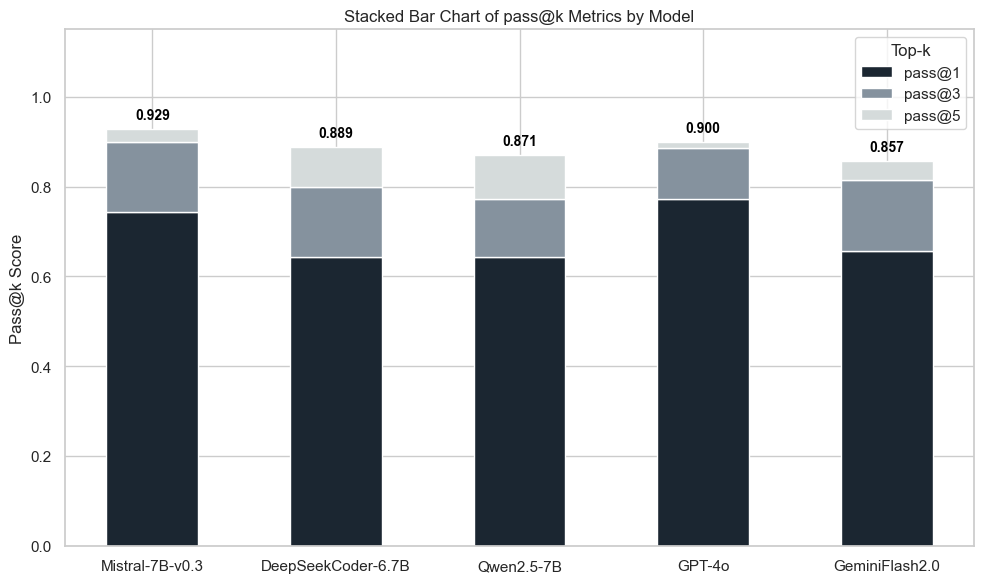

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["Mistral-7B-v0.3", "DeepSeekCoder-6.7B", "Qwen2.5-7B", "GPT-4o", "GeminiFlash2.0"]
pass_at_1 = np.array([0.7429, 0.6429, 0.6428, 0.7714, 0.6571])
pass_at_3 = np.array([0.9, 0.8, 0.7714, 0.8857, 0.8143])
pass_at_5 = np.array([0.9286, 0.8886, 0.8714, 0.9, 0.8571])

# Deltas for stacked segments
delta_3 = pass_at_3 - pass_at_1
delta_5 = pass_at_5 - pass_at_3

# Plot config
bar_width = 0.5
index = np.arange(len(models))

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each segment
ax.bar(index, pass_at_1, bar_width, label='pass@1', color='#1b2631')
ax.bar(index, delta_3, bar_width, bottom=pass_at_1, label='pass@3', color='#85929e')
bars3 = ax.bar(index, delta_5, bar_width, bottom=pass_at_3, label='pass@5', color='#d5dbdb')

# Add only pass@5 labels on top of bars
for i, bar in enumerate(bars3):
    y = pass_at_5[i]
    ax.text(bar.get_x() + bar.get_width()/2, y + 0.015, f"{y:.3f}",
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# Axis and legend setup
ax.set_ylabel("Pass@k Score")
ax.set_title("Stacked Bar Chart of pass@k Metrics by Model")
ax.set_xticks(index)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.15)
ax.legend(title="Top-k")

plt.tight_layout()
plt.savefig("Fig14.png", dpi=300, bbox_inches='tight')
plt.show()


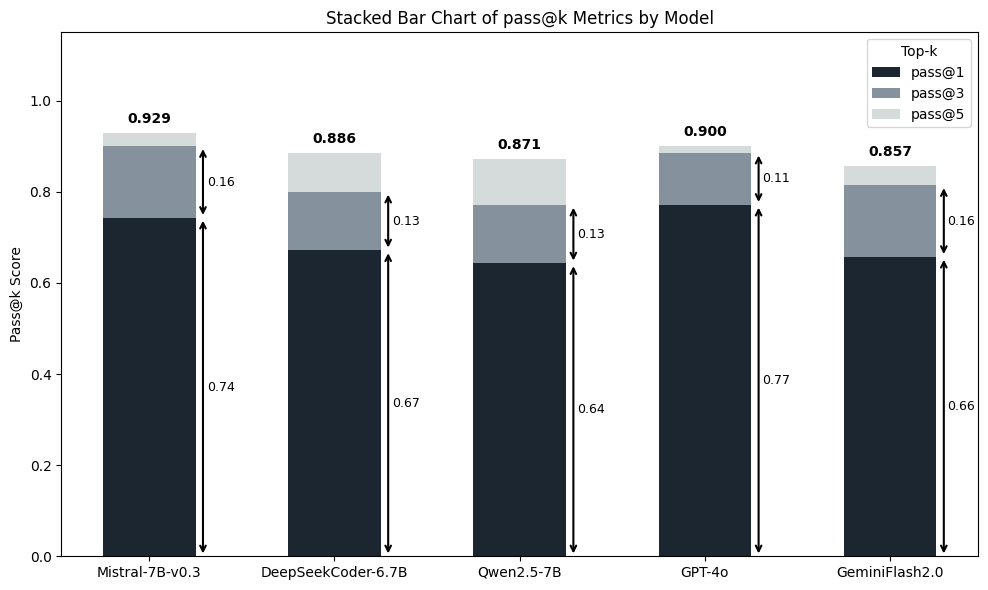

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["Mistral-7B-v0.3", "DeepSeekCoder-6.7B", "Qwen2.5-7B", "GPT-4o", "GeminiFlash2.0"]
pass_at_1 = np.array([0.7429, 0.6714, 0.6429, 0.7714, 0.6571])
pass_at_3 = np.array([0.9, 0.8, 0.7714, 0.8857, 0.8143])
pass_at_5 = np.array([0.9286, 0.8857, 0.8714, 0.9, 0.8571])

# Deltas for stacked segments
delta_3 = pass_at_3 - pass_at_1
delta_5 = pass_at_5 - pass_at_3

# Plot config
bar_width = 0.5
index = np.arange(len(models))

fig, ax = plt.subplots(figsize=(10, 6))

# Colors
color1 = '#1b2631'
color3 = '#85929e'
color5 = '#d5dbdb'

# Plot segments
bars1 = ax.bar(index, pass_at_1, bar_width, label='pass@1', color=color1)
bars2 = ax.bar(index, delta_3, bar_width, bottom=pass_at_1, label='pass@3', color=color3)
bars3 = ax.bar(index, delta_5, bar_width, bottom=pass_at_3, label='pass@5', color=color5)

# Add total value (pass@5) on top of bars
for i, bar in enumerate(bars3):
    y = pass_at_5[i]
    ax.text(bar.get_x() + bar.get_width()/2, y + 0.015, f"{y:.3f}",
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# Function to draw a double-headed arrow and label in the middle
def draw_segment_arrow(x_center, y_start, y_end, label, color='black', offset=0.04):
    mid_y = (y_start + y_end) / 2
    ax.annotate(
        '', xy=(x_center + offset, y_start), xytext=(x_center + offset, y_end),
        arrowprops=dict(arrowstyle='<->', lw=1.5, color=color),
        annotation_clip=False
    )
    ax.text(x_center + offset + 0.02, mid_y, f"{label}", va='center', fontsize=9, color=color)

# Draw arrows for first 2 segments and only label for the third
for i in range(len(models)):
    x = index[i] + bar_width / 2

    # Segment 1: pass@1
    draw_segment_arrow(x, 0, pass_at_1[i], f"{pass_at_1[i]:.2}")

    # Segment 2: pass@3 - pass@1
    draw_segment_arrow(x, pass_at_1[i], pass_at_3[i], f"{delta_3[i]:.2f}")

    # Segment 3: pass@5 - pass@3 (value only, no arrow)
    #mid_y = (pass_at_5[i] + pass_at_3[i]) / 2
    #ax.text(x + 0.07, mid_y, f"{delta_5[i]:.2f}", va='center', fontsize=9, color='black')

# Axis and legend setup
ax.set_ylabel("Pass@k Score")
ax.set_title("Stacked Bar Chart of pass@k Metrics by Model")
ax.set_xticks(index)
ax.set_xticklabels(models, rotation=0)
ax.set_ylim(0, 1.15)
#ax.grid()
ax.legend(title="Top-k")

plt.tight_layout()
plt.savefig("Fig14_label_only_last.png", dpi=300, bbox_inches='tight')
plt.show()


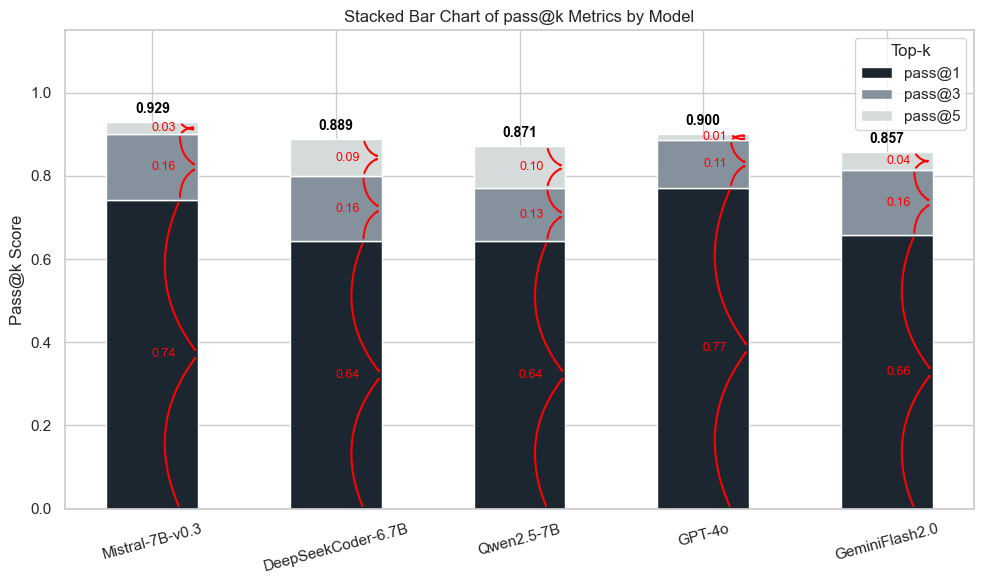

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

# Data
models = ["Mistral-7B-v0.3", "DeepSeekCoder-6.7B", "Qwen2.5-7B", "GPT-4o", "GeminiFlash2.0"]
pass_at_1 = np.array([0.7429, 0.6429, 0.6428, 0.7714, 0.6571])
pass_at_3 = np.array([0.9, 0.8, 0.7714, 0.8857, 0.8143])
pass_at_5 = np.array([0.9286, 0.8886, 0.8714, 0.9, 0.8571])

# Deltas for stacked segments
delta_3 = pass_at_3 - pass_at_1
delta_5 = pass_at_5 - pass_at_3

# Plot config
bar_width = 0.5
index = np.arange(len(models))

fig, ax = plt.subplots(figsize=(10, 6))

# Colors
color1 = '#1b2631'
color3 = '#85929e'
color5 = '#d5dbdb'

# Plot segments
bars1 = ax.bar(index, pass_at_1, bar_width, label='pass@1', color=color1)
bars2 = ax.bar(index, delta_3, bar_width, bottom=pass_at_1, label='pass@3', color=color3)
bars3 = ax.bar(index, delta_5, bar_width, bottom=pass_at_3, label='pass@5', color=color5)

# Add total value (pass@5) on top of bars
for i, bar in enumerate(bars3):
    y = pass_at_5[i]
    ax.text(bar.get_x() + bar.get_width()/2, y + 0.015, f"{y:.3f}",
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

# Function to draw curved inward arrow toward bar segment
def draw_curved_arrow(ax, x_center, y_bottom, y_top, label, color='red', dx=0.1, curvature=0.3):
    mid_y = (y_top + y_bottom) / 2

    # Curved arrow from bottom to center
    arrow1 = FancyArrowPatch(
        posA=(x_center - dx, y_bottom),
        posB=(x_center, mid_y),
        connectionstyle=f"arc3,rad={-curvature}",
        arrowstyle='->',
        color=color,
        lw=1.5
    )
    ax.add_patch(arrow1)

    # Curved arrow from top to center
    arrow2 = FancyArrowPatch(
        posA=(x_center - dx, y_top),
        posB=(x_center, mid_y),
        connectionstyle=f"arc3,rad={curvature}",
        arrowstyle='->',
        color=color,
        lw=1.5
    )
    ax.add_patch(arrow2)

    # Label in the center of the curve
    ax.text(x_center - dx - 0.02, mid_y, f"{label}", va='center', ha='right', fontsize=9, color=color)

# Add curved arrows for each segment
for i in range(len(models)):
    x = index[i] + bar_width / 2

    # pass@1 segment
    draw_curved_arrow(ax, x, 0, pass_at_1[i], f"{pass_at_1[i]:.2f}")

    # pass@3 segment
    draw_curved_arrow(ax, x, pass_at_1[i], pass_at_3[i], f"{delta_3[i]:.2f}")

    # pass@5 segment
    draw_curved_arrow(ax, x, pass_at_3[i], pass_at_5[i], f"{delta_5[i]:.2f}")

# Axis and legend setup
ax.set_ylabel("Pass@k Score")
ax.set_title("Stacked Bar Chart of pass@k Metrics by Model")
ax.set_xticks(index)
ax.set_xticklabels(models, rotation=15)
ax.set_ylim(0, 1.15)
ax.legend(title="Top-k")

plt.tight_layout()
plt.savefig("Fig14_curved_arrows.png", dpi=300, bbox_inches='tight')
plt.show()
